In [6]:
import pandas as pd
import csv
import pickle
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import os
import random
from itertools import product


from stage1 import lasso_rolling_window, calculate_r_squared
from stage2 import estimate_kappa_curve_fit, compute_alm_returns, compute_stage2_r_squared
from grid_search import grid_search

In [7]:
# load feature matrix and response variable
feature_matrix = pd.read_csv("../../data/merged_return_topic_data.csv", index_col=0, parse_dates=True)
response_variables = pd.read_csv("../../data/response.csv", index_col=0, parse_dates=True)

In [8]:
# select a response variable (either marekt return or sp500 return)
y = response_variables['sprtrn']  # or 'sprtrn' for SP500 returns or vwretx
# transform returns to log
y = np.log(y+1)

# create feature matrix
X = feature_matrix.copy()
random.seed(42)

# Separate topic (name) and stock (numeric) columns
topic_cols = [col for col in X.columns if not str(col).isdigit()]
stock_cols = [col for col in X.columns if str(col).isdigit()]

# User-selected number of each (or use len(...) for "all")
num_topics = len(topic_cols)  # e.g., 100
num_stocks = 0

# Randomly sample (without replacement), limited by available count
selected_topics = random.sample(topic_cols, min(num_topics, len(topic_cols)))
selected_stocks = random.sample(stock_cols, min(num_stocks, len(stock_cols)))

# Final filtered dataframe
X = X[selected_topics + selected_stocks]

# Convert stock returns to log returns: log(1+r)
X[selected_stocks] = np.log(X[selected_stocks] + 1)

# ensure that all indices align
common_index = X.index.intersection(y.index)
X = X.loc[common_index]
y = y.loc[common_index]

In [9]:
# Cell in your notebook
param_grid = {
    'window_sizes': [31],
    'n_lags': [1,2],
    'lambdas': [0.005]
}

summary_df, coefficients_df = grid_search(X, y, param_grid, verbose=True)

Testing 2 configurations...


Grid search: 100%|██████████| 2/2 [00:00<00:00, 514.26it/s]



GRID SEARCH COMPLETE


In [10]:
summary_df

,window_size,n_lags,lambda,r2_insample_stage1,r2_oos_stage1,r2_insample_stage2,r2_oos_stage2,kappa,kappa_tstat,intercept,intercept_tstat,n_observations,n_windows,n_oos_predictions_stage2
0,31,1,0.005,0.030039,-0.081583,-0.002236,-0.014743,0.086706,1.535974,0.000425,1.926657,1856,1857,1755
1,31,2,0.005,0.052677,-0.063614,-0.004980,-0.034856,0.127059,2.311971,0.000422,1.912366,1855,1856,1754


In [6]:
# Define your grid
param_grid = {
    'window_sizes': [30,60,100,200,300,500],
    'n_lags': [1,2,3,5,8],
    'lambdas': [0.01,0.001,0.0001,0.00001,0.000005,0.000001]
}

# Run grid search 
results_df1 = grid_search(X, y, param_grid, verbose=True)

# Save
results_df1.to_csv('grid_search_results8.csv', index=False)

Testing 180 configurations...


Grid search:   0%|          | 0/180 [00:00<?, ?it/s]

2.6603568458168103e-05
-4.76087902466124e-05
-6.876624280708306e-06
-0.0001473123827901566
6.30575064328771e-05
-1.6560994270892924e-05
1.991595418724228e-06
0.00012740227045235751
-4.797733626419425e-06
-5.2587679473928934e-05
2.1074717248468153e-06
-0.00024744221458880273
-1.9209448269709274e-07
-4.724039503176904e-05
2.110930983597137e-05
-7.902133100562062e-05
-9.075144753035147e-06
-2.5472227060581216e-05
-1.9838466108813796e-06
-0.0003922124738612103
-8.47468957381798e-05
-0.0008160121947268554
-9.55160647894479e-05
-4.496573993495616e-05
-1.3503988418909208e-06
2.749318091774377e-05
-2.040683423308541e-05
-2.51594600874209e-05
-6.712414843897106e-06
-0.0002228356903840204
8.940806230272513e-08
5.833606189729188e-06
-9.234128382490687e-05
3.731336488265428e-05
1.0039107866372855e-05
-1.787010255455353e-05
2.5745638081328712e-05
1.6028036999797324e-06
-1.020888288804549e-05
-1.8591741151478804e-05
-2.1179000830876426e-06
-4.371539960608396e-05
5.848850337685773e-07
-3.887247668568

KeyboardInterrupt: 

In [ ]:
grid_results = pd.read_csv("grid_search_results5.csv")

In [ ]:
print(grid_results.head(10))

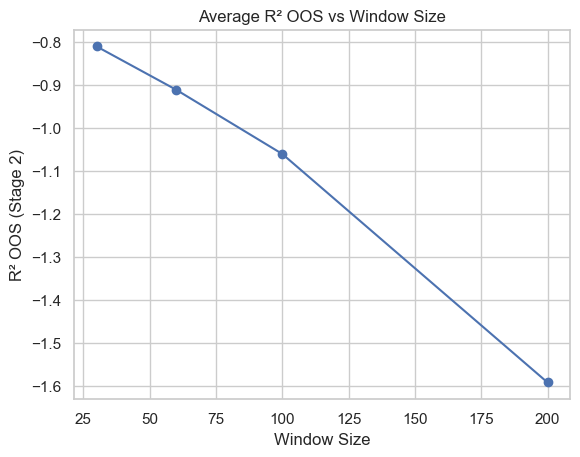

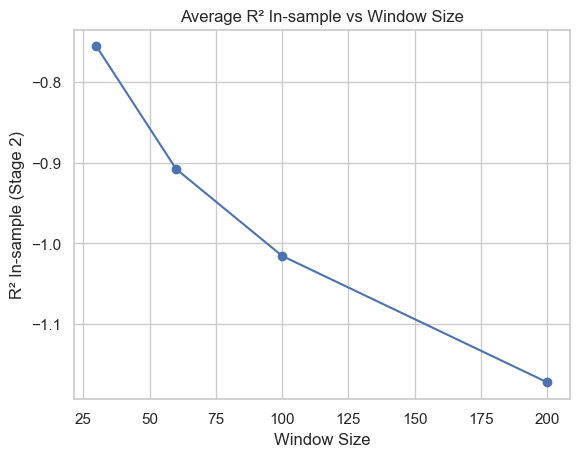

In [ ]:
# Compute average metrics per window size
avg = grid_results.groupby('window_size', as_index=False)[
    ['r2_oos_stage2', 'r2_insample_stage2']
].mean()

# Plot Avg R2 OOS vs window size
plt.figure()
plt.plot(avg['window_size'], avg['r2_oos_stage2'], marker='o')
plt.xlabel('Window Size')
plt.ylabel('R² OOS (Stage 2)')
plt.title('Average R² OOS vs Window Size')
plt.grid(True)
plt.show()

# Plot Avg R2 In-sample vs window size
plt.figure()
plt.plot(avg['window_size'], avg['r2_insample_stage2'], marker='o')
plt.xlabel('Window Size')
plt.ylabel('R² In-sample (Stage 2)')
plt.title('Average R² In-sample vs Window Size')
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Plot R2 oos stage2 vs lambda
plt.figure()
plt.scatter(grid_results['window_size'], grid_results['r2_oos_stage2'])
# plt.xscale('log')
plt.xlabel('lambda (log scale)')
plt.ylabel('R² (OOS stage 2)')
plt.title('R² vs lambda (log scale)')
plt.show()

# Plot R2 in sample stage2 vs lambda
plt.figure()
plt.scatter(grid_results['window_size'], grid_results['r2_insample_stage2'])
# plt.xscale('log')
plt.xlabel('lambda (log scale)')
plt.ylabel('R² (OOS stage 2)')
plt.title('R² vs lambda (log scale)')
plt.show()

# Plot kappa vs lambda
plt.figure()
plt.scatter(grid_results['lambda'], grid_results['kappa'])
plt.xscale('log')
plt.xlabel('lambda (log scale)')
plt.ylabel('kappa')
plt.title('Kappa vs lambda (log scale)')
plt.show()


In [ ]:
metrics = grid_results[['lambda', 'n_lags', 'window_size']].corrwith(grid_results['kappa']).abs()
print(metrics.sort_values(ascending=False))